# Dispersion, Five-Point Summary & Skewness

Knowing *where* data is centred (central tendency) is only half the picture. Dispersion measures tell us *how spread out* the data is, and skewness tells us *which direction* it leans.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


## Measures of Dispersion

| Measure | Formula | Strength | Weakness |
|---|---|---|---|
| **Range** | max − min | Simple | Captures only extreme values |
| **Variance** | avg squared deviation | Uses all data | In squared units; hard to interpret |
| **Std Dev** | √variance | Same units as data | Sensitive to outliers |
| **IQR** | Q3 − Q1 | Robust to outliers | Ignores tails |

In [2]:
for col in ['age', 'fare']:
    data = df[col].dropna()
    print(f"=== {col.upper()} ===")
    print(f"  Range:    {data.max() - data.min():.2f}")
    print(f"  Variance: {data.var():.2f}")
    print(f"  Std Dev:  {data.std():.2f}")
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    print(f"  IQR:      {q3 - q1:.2f}")
    print()

=== AGE ===
  Range:    79.58
  Variance: 211.02
  Std Dev:  14.53
  IQR:      17.88

=== FARE ===
  Range:    512.33
  Variance: 2469.44
  Std Dev:  49.69
  IQR:      23.09



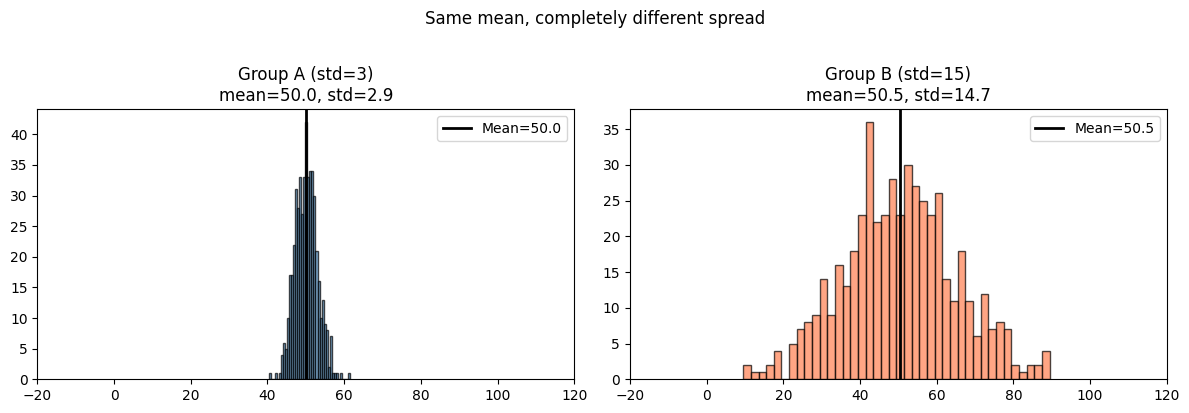

In [3]:
# Why dispersion matters: two groups with the same mean but different spreads
np.random.seed(42)
group_a = np.random.normal(50, 3, 500)   # tight
group_b = np.random.normal(50, 15, 500)  # wide

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, label, color in [
    (axes[0], group_a, 'Group A (std=3)',  'steelblue'),
    (axes[1], group_b, 'Group B (std=15)', 'coral')
]:
    ax.hist(data, bins=40, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(data.mean(), color='black', linewidth=2, label=f'Mean={data.mean():.1f}')
    ax.set_title(f'{label}\nmean={data.mean():.1f}, std={data.std():.1f}')
    ax.set_xlim(-20, 120)
    ax.legend()

plt.suptitle('Same mean, completely different spread', y=1.02)
plt.tight_layout()
plt.show()

## Five-Point Summary

A compact description of a distribution using five key statistics:

| Statistic | Percentile | Meaning |
|---|---|---|
| **Min** | 0th | Smallest observation |
| **Q1** | 25th | Lower quartile — 25% of data below this |
| **Median (Q2)** | 50th | Middle value |
| **Q3** | 75th | Upper quartile — 75% of data below this |
| **Max** | 100th | Largest observation |

**IQR = Q3 − Q1** spans the middle 50% of the data.

In [4]:
print("Five-point summary — Age:")
print(df['age'].describe().round(2))
print()
print("Five-point summary — Fare:")
print(df['fare'].describe().round(2))

Five-point summary — Age:
count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: age, dtype: float64

Five-point summary — Fare:
count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64


## Boxplot — Visualising the Five-Point Summary

A boxplot encodes all five statistics visually:

```
         Min   Q1   Median  Q3    Max
          |----[=====|=====]----|
                               outliers: o
```

- The **box** spans Q1 to Q3 (IQR)
- The **line** inside is the median
- The **whiskers** extend to 1.5 × IQR beyond the box
- **Points** beyond whiskers are potential outliers

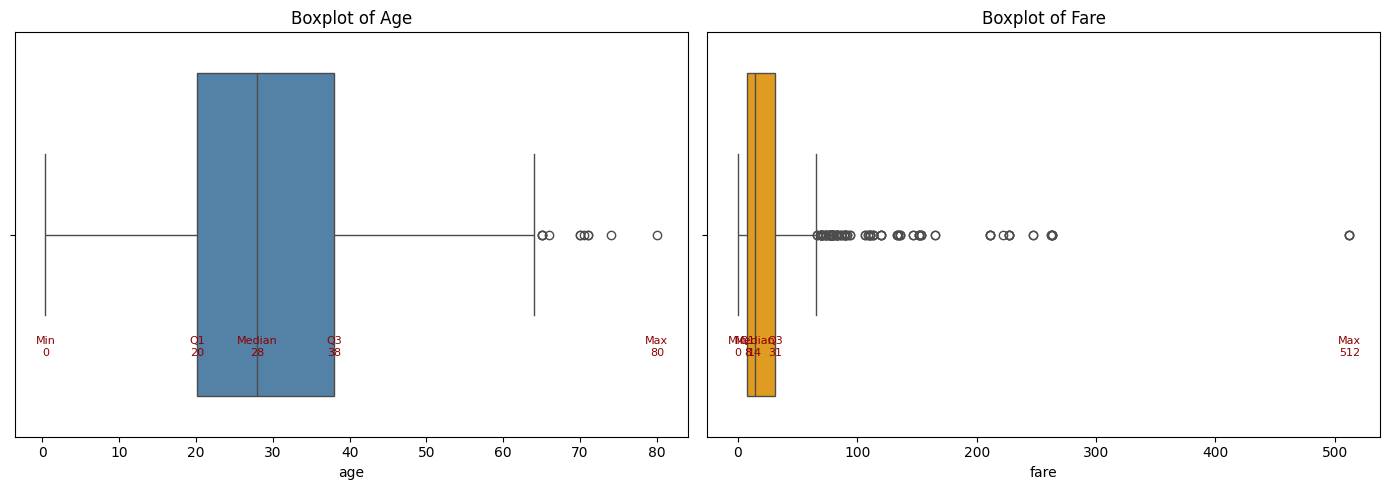

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in [(axes[0], 'age', 'steelblue'), (axes[1], 'fare', 'orange')]:
    data = df[col].dropna()
    stats_5 = data.describe()

    sns.boxplot(x=data, ax=ax, color=color)
    ax.set_title(f'Boxplot of {col.capitalize()}')

    # Annotate the five points
    for stat, key, offset in [
        ('Min', 'min', 0.3), ('Q1', '25%', 0.3),
        ('Median', '50%', 0.3), ('Q3', '75%', 0.3), ('Max', 'max', 0.3)
    ]:
        ax.text(stats_5[key], offset, f'{stat}\n{stats_5[key]:.0f}',
                ha='center', fontsize=8, color='darkred')

plt.tight_layout()
plt.show()

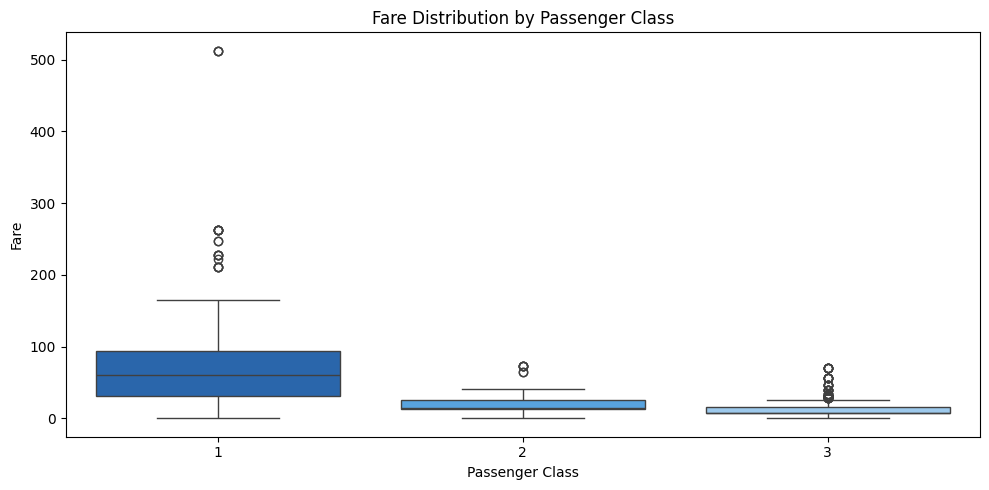

In [6]:
# Side-by-side boxplots for group comparison
plt.figure(figsize=(10, 5))
sns.boxplot(x='pclass', y='fare', data=df,
            palette=['#1565C0', '#42A5F5', '#90CAF9'])
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

## Skewness — Shape of the Distribution

Skewness measures asymmetry relative to a normal (bell-shaped) curve.

| Skewness value | Distribution | Mean vs Median |
|---|---|---|
| > +0.5 | Right-skewed (positive) | Mean > Median |
| −0.5 to +0.5 | Approximately symmetric | Mean ≈ Median |
| < −0.5 | Left-skewed (negative) | Mean < Median |

**Right-skewed**: long tail to the right (income, house prices, fare)  
**Left-skewed**: long tail to the left (age at death, test scores for easy exams)

In [7]:
# Calculate skewness for all numerical columns
print("Skewness values:")
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    sk = df[col].skew()
    direction = 'right-skewed' if sk > 0.5 else ('left-skewed' if sk < -0.5 else 'symmetric')
    print(f"  {col:12s}: {sk:7.3f}  → {direction}")

Skewness values:
  survived    :   0.479  → symmetric
  pclass      :  -0.631  → left-skewed
  age         :   0.389  → symmetric
  sibsp       :   3.695  → right-skewed
  parch       :   2.749  → right-skewed
  fare        :   4.787  → right-skewed


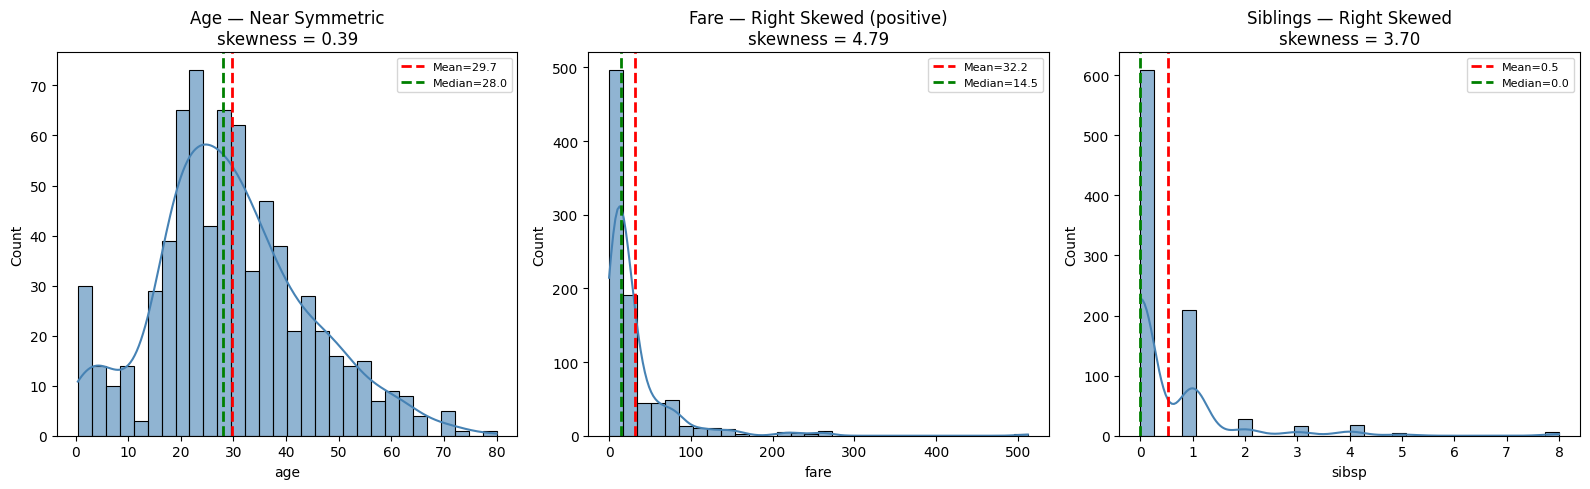

In [8]:
# Visualise right-skew vs symmetric
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

examples = [
    ('age',  'Age — Near Symmetric'),
    ('fare', 'Fare — Right Skewed (positive)'),
    ('sibsp','Siblings — Right Skewed')
]

for ax, (col, title) in zip(axes, examples):
    data = df[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color='steelblue', alpha=0.6)
    ax.axvline(data.mean(),   color='red',   linestyle='--', lw=2, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='--', lw=2, label=f'Median={data.median():.1f}')
    ax.set_title(f'{title}\nskewness = {data.skew():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

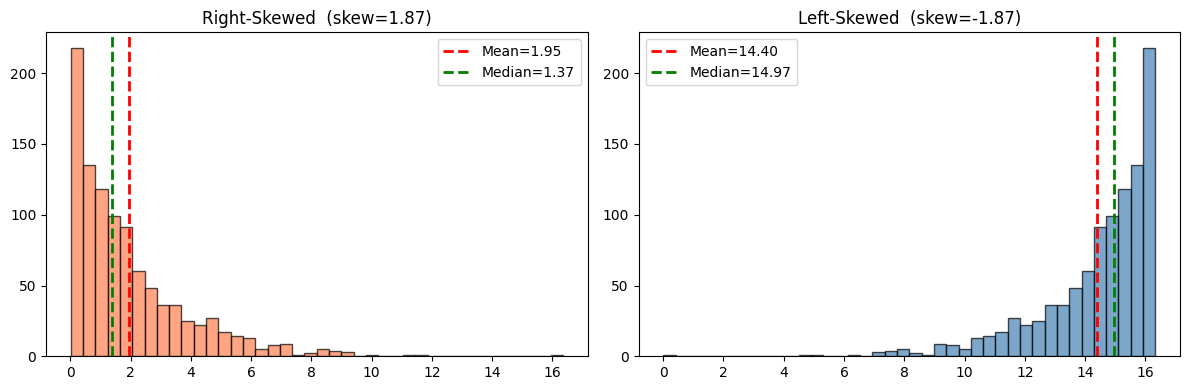

In [9]:
# Constructing a left-skewed example
np.random.seed(42)
# Reflect a right-skewed distribution to get left-skew
right_skewed = np.random.exponential(scale=2, size=1000)
left_skewed  = right_skewed.max() - right_skewed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(right_skewed, bins=40, color='coral',     edgecolor='black', alpha=0.7)
axes[0].axvline(right_skewed.mean(),   color='red',   linestyle='--', lw=2, label=f'Mean={right_skewed.mean():.2f}')
axes[0].axvline(np.median(right_skewed), color='green', linestyle='--', lw=2, label=f'Median={np.median(right_skewed):.2f}')
axes[0].set_title(f'Right-Skewed  (skew={pd.Series(right_skewed).skew():.2f})')
axes[0].legend()

axes[1].hist(left_skewed, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(left_skewed.mean(),    color='red',   linestyle='--', lw=2, label=f'Mean={left_skewed.mean():.2f}')
axes[1].axvline(np.median(left_skewed), color='green', linestyle='--', lw=2, label=f'Median={np.median(left_skewed):.2f}')
axes[1].set_title(f'Left-Skewed  (skew={pd.Series(left_skewed).skew():.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

## Key Takeaways

| Measure | Robust to outliers? | Use for |
|---|---|---|
| Range | No | Quick total spread |
| Std Dev | No | Symmetric data spread |
| IQR | Yes | Skewed data, outlier fences |
| Five-point summary | Yes | Distribution snapshot |
| Boxplot | Yes | Comparing distributions across groups |

**Skewness rules of thumb**:
- |skew| < 0.5 → symmetric → use mean
- |skew| > 1 → strongly skewed → use median, consider log transform